In [ ]:
import numpy as np
import pandas as pd
from numpy.lib.stride_tricks import as_strided
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
import seaborn as sns
from pathlib import Path
from scipy.signal import butter, filtfilt


In [ ]:

# ==================== CONFIG ====================
WINDOW_SIZE = 29
OVERLAP = 14
TEST_RATIO = 0.20
VAL_RATIO  = 0.20

RANDOM_STATE = 42
N_JOBS = -1  # -1 = all CPUs
N_ESTIMATORS = 1000 # number of trees in the forest
MAX_DEPTH = None  # None = nodes are expanded until all leaves are pure

DATA_PATH = Path("Datasets and splits/Freegait/FreeGait/FreeGait/native_csv_export/kp3d_native_wide.csv")

MAX_SESSIONS = None  # None = all sessions
# ================================================


In [3]:
def Torso_centering(group, joints_col):
    for axis in "xyz":
        cols = [c for c in joints_col if c.endswith(f"_{axis}")]
        torso_col = f"joint_torso_{axis}"
        cols_wo_torso = [c for c in cols if c != torso_col]

        before = group[cols_wo_torso].to_numpy(copy=True)
        group.loc[:, cols] = group.loc[:, cols].sub(group[torso_col], axis=0)
        after = group[cols_wo_torso].to_numpy()

        became_zero = (~np.isclose(before, 0.0, atol=1e-6)) & (np.isclose(after, 0.0, atol=1e-6))
        per_col = became_zero.sum(axis=0)

        for col, cnt in zip(cols_wo_torso, per_col):
            if cnt > 0:
                print(f"{col}: {cnt} values became zero due to centering")

    return group



In [4]:
import numpy as np

def fix_missdetected_joints(group, max_gap=500000, min_dup=4):
    #max gap for one second in this work because fps is 6
    """
    If, within the same frame, >= min_dup joints have EXACTLY the same (x,y,z),
    mark those joints as NaN and fill over time using linear interpolation.
    """
    joints = [
    "pelvis",
    "spine1", "spine2", "spine3",
    "neck", "head",

    "left_collar", "right_collar",
    "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow",
    "left_wrist", "right_wrist",
    "left_hand", "right_hand",
    "left_hip", "right_hip",
    "left_knee", "right_knee",
    "left_ankle", "right_ankle",
    "left_foot", "right_foot",

]

    #copy data frame 
    group = group.copy()
    #Build joint coordinate column names
    cols = [f"joint_{j}_{a}" for j in joints for a in "xyz"]
    #Convert to numpy and reshape to (T,J,3) where T is number of frames, J is number of joints
    arr = group[cols].to_numpy(float).reshape(len(group), len(joints), 3)
    #Mask for missdetected joints
    bad = np.zeros((len(group), len(joints)), dtype=bool)
    #Loop through each frame and find duplicates
    for t in range(len(group)):
        frame = arr[t]  # (J,3)
        #Ignore joints that already have NaNs in case it got used by CLS 
        valid = ~np.isnan(frame).any(axis=1)
        if valid.sum() < 2:
            continue

        # Find exact duplicate 3D coordinates in that frame
        uniq, inv, counts = np.unique(frame[valid], axis=0,
                                      return_inverse=True, return_counts=True)
        #Keep only coordinates repeated at least min_dup times
        dup_ids = np.where(counts >= min_dup)[0]
        if dup_ids.size == 0:
            continue
        #Mark those joints as bad
        dup_valid_mask = np.isin(inv, dup_ids)
        joint_idx = np.where(valid)[0][dup_valid_mask]
        joint_idx = joint_idx[joint_idx != pelvis_idx] # but never the torso
        bad[t, joint_idx] = True

    # Set duplicated joints to NaN (all 3 axes)
    arr[bad] = np.nan
    group.loc[:, cols] = arr.reshape(len(group), -1)

    # Fill from previous + next frames
    group.loc[:, cols] = (
        group.loc[:, cols]
             .interpolate(method="linear", limit=max_gap, limit_direction="both")
             .ffill(limit=max_gap)
             .bfill(limit=max_gap)
    )

    return group


In [5]:
import numpy as np

def frequency_features(X_windows, fps, feat_cols,
                           bands=((0.3, 1.0), (1.0, 2.0)),
                           detrend=True, eps=1e-12):
    """
    Returns per window:
      - total FFT power per joint
      - normalized band power per band per joint
    Output shape: (Nw, F * (1 + len(bands)))
    """
    # Convert to numpy array
    X = np.asarray(X_windows, np.float32)
    # Get dimensions: Number of windows, Time points, Features
    Nw, T, F = X.shape
    #computes the frequencies with spacing of fps/T where T is number of frames, freqs[k] is the k-th frequency. d is
    freqs = np.fft.rfftfreq(T, d=1.0 / fps)
    """
    how much of frequency bin k is in signal f during window w  
    compute power spectrum of the signal, the FFT is computed along the time axis (axis=1) and is a complex number (phase and amplitude).
    it ignores the phase and computes the power spectrum by taking the squared magnitude. 
    """
    P = np.abs(np.fft.rfft(X, axis=1))**2          # (Nw, K, F)
    # sumes the power spectral density across frequency bins to obtain the total power for each window and feature.
    total = P.sum(axis=1) + eps                    # (Nw, F)
    #initialize output list and names
    out = [total]
    names = [f"fft_total__{c}" for c in feat_cols]
    # For each band, sum power in that band and normalize by total power
    for flo, fhi in bands:
        # if m is between flo and fhi where flo and fhi are the lower and upper frequency bounds of the band, to see which frequencies belong to that band
        m = (freqs >= flo) & (freqs < fhi)
        #
        band = P[:, m, :].sum(axis=1)              # (Nw, F)
        out.append(band / total)                   # normalized
        names += [f"fft_ratio_{flo:g}_{fhi:g}Hz__{c}" for c in feat_cols]

    return np.concatenate(out, axis=1).astype(np.float32), names


In [6]:

def compute_bone_lengths(group, joint_cols):
    # Precompute index maps
    coords = ("x", "y", "z")
    col2i = {c: i for i, c in enumerate(joint_cols)}

    joints = [
    "pelvis",
    "spine1", "spine2", "spine3",
    "neck", "head",

    "left_collar", "right_collar",
    "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow",
    "left_wrist", "right_wrist",
    "left_hand", "right_hand",
    "left_hip", "right_hip",
    "left_knee", "right_knee",
    "left_ankle", "right_ankle",
    "left_foot", "right_foot",

]

    idx = {j: [col2i[f"joint_{j}_{c}"] for c in coords] for j in joints}

    bones = [
    # spine / head
    ("pelvis", "spine1"),
    ("spine1", "spine2"),
    ("spine2", "spine3"),
    ("spine3", "neck"),
    ("neck", "head"),

    # left arm
    ("spine3", "left_collar"),
    ("left_collar", "left_shoulder"),
    ("left_shoulder", "left_elbow"),
    ("left_elbow", "left_wrist"),
    ("left_wrist", "left_hand"),

    # right arm
    ("spine3", "right_collar"),
    ("right_collar", "right_shoulder"),
    ("right_shoulder", "right_elbow"),
    ("right_elbow", "right_wrist"),
    ("right_wrist", "right_hand"),
    # left leg
    ("pelvis", "left_hip"),
    ("left_hip", "left_knee"),
    ("left_knee", "left_ankle"),
    ("left_ankle", "left_foot"),

    

    # right leg
    ("pelvis", "right_hip"),
    ("right_hip", "right_knee"),
    ("right_knee", "right_ankle"),
    ("right_ankle", "right_foot"),
     ]

    pos = group[joint_cols].to_numpy(dtype=np.float32)

    bone_col = [f"{a}_{b}_len" for a, b in bones]

    P = {j: pos[:, idx[j]] for j in joints}
    bone_len = np.column_stack([
        np.linalg.norm(P[a] - P[b], axis=1) for a, b in bones
    ]).astype(np.float32)

    return bone_len, bone_col


In [7]:
import numpy as np

def make_windows(seq, label, window_size, step, pad_mode="edge"):
    """
    pad_mode:
      - "edge": repeat last frame 
      - "zero": pad with zeros
    """
    out_X, out_y = [], []
    T = len(seq)

    if T == 0:
        return out_X, out_y

    # If too short: pad and return exactly 1 window
    if T < window_size:
        seq = np.asarray(seq)
        pad_len = window_size - T

        if pad_mode == "edge":
            pad = np.repeat(seq[-1][None, :], pad_len, axis=0)
        elif pad_mode == "zero":
            pad = np.zeros((pad_len, seq.shape[1]), dtype=seq.dtype)
        else:
            raise ValueError("pad_mode must be 'edge' or 'zero'")

        win = np.vstack([seq, pad])
        out_X.append(win)
        out_y.append(label)
        return out_X, out_y

    # Normal sliding windows
    for start in range(0, T - window_size + 1, step):
        out_X.append(seq[start:start + window_size])
        out_y.append(label)

    return out_X, out_y


In [8]:
from scipy.signal import butter, filtfilt

def winter_velocity (group,joints_col,fps,fc):
    pos = group[joints_col].to_numpy(dtype=np.float32)
    N, D = pos.shape
    dt = 1.0 / fps
    J = D // 3
        # --- 3D velocity first ---
    if N < 2:
        vel = np.zeros((N, D), dtype=np.float32)
    else:
        vel = np.gradient(pos, dt, axis=0).astype(np.float32)  # (N, 3J)
    # --- convert to speed per joint ---
    vel3 = vel.reshape(N, J, 3)                         # (N, J, 3)
    speed_raw = np.linalg.norm(vel3, axis=2).astype(np.float32)  # (N, J)
    # Butterworth low-pass for velocity w stands for 
    w = fc / (fps / 2.0)
    if not (0 < w < 1):
        raise ValueError(f"Bad cutoff: fc={fc} with fps={fps} gives normalized Wn={w} (must be in (0,1))")

    b, a = butter(N=2, Wn=w, btype="low")
    
    padlen = 3 * (max(len(a), len(b)) - 1)  # filtfilt requirement

    speed = filtfilt(b, a, speed_raw, axis=0) if N > padlen else speed_raw
    speed = speed.astype(np.float32)
    # filtfilt can fail on very short sequences; fall back to raw
        # labels: take every *_x col as joint base name
    joint_names = []
    for c in joints_col[::3]:
        parts = c.split("_")              # joint_left_knee_x
        joint_names.append("_".join(parts[1:-1]))  # left_knee
    speed_labels = [f"speed_{j}" for j in joint_names]
    return speed, speed_labels

In [9]:
def stats_for_windows(X,feat_cols):
    # base stats
    mean  =np.nanmean(X,axis=1)
    print('mean',mean)
    std   = np.nanstd(X,axis=1)
    print('std',std)
    min_  = np.nanmin(X,axis=1)
    print('min_',min_)
    max_  = np.nanmax(X,axis=1)
    print('max_',max_)
    rng   = max_ - min_
    base = np.concatenate([mean, std, min_, max_, rng], axis=1)

    stats = ["mean","std","min","max","range"]
    stats_names = [f"{s}__{n}" for s in stats for n in feat_cols]
    return base, stats_names     


In [10]:
import numpy as np

def angle_ABC(A, B, C, eps=1e-8):
    """
    Angle at B formed by points A-B-C.
    A,B,C: (T,3)
    returns: (T,1)
    """
    BA = A - B
    BC = C - B
    num = np.sum(BA * BC, axis=1, keepdims=True)
    den = (np.linalg.norm(BA, axis=1, keepdims=True) * np.linalg.norm(BC, axis=1, keepdims=True) + eps)
    cosang = np.clip(num / den, -1.0, 1.0)
    return np.arccos(cosang)  # radians

def get_joint_xyz(group, name):
    return group[[f"joint_{name}_x", f"joint_{name}_y", f"joint_{name}_z"]].to_numpy(dtype=np.float32)

def compute_angle_features(group, fps):
    pelvis = get_joint_xyz(group, "pelvis")
    spine3 = get_joint_xyz(group, "spine3")
    spine2 = get_joint_xyz(group, "spine2")
    spine1 = get_joint_xyz(group, "spine1")
    neck = get_joint_xyz(group, "neck")


    lh, lk, la = (get_joint_xyz(group, "left_hip"),
                  get_joint_xyz(group, "left_knee"),
                  get_joint_xyz(group, "left_ankle"))
    rh, rk, ra = (get_joint_xyz(group, "right_hip"),
                  get_joint_xyz(group, "right_knee"),
                  get_joint_xyz(group, "right_ankle"))
    
    lk, la, lf = (get_joint_xyz(group, "left_knee"),
                  get_joint_xyz(group, "left_ankle"),
                  get_joint_xyz(group, "left_foot"))
    
    rk, ra, rf = (get_joint_xyz(group, "right_knee"),
                  get_joint_xyz(group, "right_ankle"),
                  get_joint_xyz(group, "right_foot"))
    
    ls, le, lw = (get_joint_xyz(group, "left_shoulder"),
                  get_joint_xyz(group, "left_elbow"),
                  get_joint_xyz(group, "left_wrist"))
    rs, re, rw = (get_joint_xyz(group, "right_shoulder"),
                  get_joint_xyz(group, "right_elbow"),
                  get_joint_xyz(group, "right_wrist"))
    
    lc, ls, le = (get_joint_xyz(group, "left_collar"),
                  get_joint_xyz(group, "left_shoulder"),
                  get_joint_xyz(group, "left_elbow"))
    rc, rs, re = (get_joint_xyz(group, "right_collar"),
                  get_joint_xyz(group, "right_shoulder"),
                  get_joint_xyz(group, "right_elbow"))
    

    # angles (T,1)
    knee_L = angle_ABC(lh, lk, la)
    knee_R = angle_ABC(rh, rk, ra)
    ankel_L=angle_ABC(lk, la, lf)
    ankel_R=angle_ABC(rk, ra, rf)
    shoulder_L=angle_ABC(lc, ls, le)
    shoulder_R=angle_ABC(rc, rs, re)
    hip_L  = angle_ABC(pelvis, lh, lk)
    hip_R  = angle_ABC(pelvis, rh, rk)
    elbow_L = angle_ABC(ls, le, lw)
    elbow_R = angle_ABC(rs, re, rw)

    # simple trunk bend proxy: angle(pelvis–spine3–neck) 
    neck = get_joint_xyz(group, "neck")
    trunk = angle_ABC(pelvis, spine3, neck)

    ang = np.concatenate([knee_L, knee_R, hip_L, hip_R, elbow_L, elbow_R, shoulder_L, shoulder_R, ankel_L, ankel_R, trunk], axis=1)

    # angular velocity (finite diff)
    dang = np.vstack([np.zeros((1, ang.shape[1]), dtype=np.float32), np.diff(ang, axis=0)]) * fps
    
    feat = np.concatenate([ang, dang], axis=1).astype(np.float32)

    names = [
        "ang_knee_L","ang_knee_R","ang_hip_L","ang_hip_R","ang_elbow_L","ang_elbow_R","ang_shoulder_L","ang_shoulder_R","ang_ankle_L","ang_ankle_R","ang_trunk",
        "dang_knee_L","dang_knee_R","dang_hip_L","dang_hip_R","dang_elbow_L","dang_elbow_R","dang_shoulder_L","dang_shoulder_R","dang_ankle_L","dang_ankle_R","dang_trunk",
    ]
    return feat, names


In [11]:
import numpy as np

def preprocess_features_split_native(
    df,
    window_size,
    overlap,
    test_session_ratio=0.20,
    seed=42,
    fps=10,
    fc=2.5,
    min_seqs_per_person=50,          # keep only persons with >= this many eligible sessions
    max_seqs_per_person=None,       # optional cap per person (helps balancing)
    remove_trajectory=True,         # pelvis-center before velocity/features
    use_padded_windows=True,       # if True, use make_windows_padded instead of make_windows
):
    """
    

    Returns:
      X_train: (Ntr, window_size, F)
      y_train: (Ntr,)
      X_test:  (Nts, window_size, F)
      y_test:  (Nts,)
      feat_cols: list[str]
    """

    # -------------------------------
    # 0) session_id
    # -------------------------------
    if "session_id" not in df.columns:
        df = df.copy()
        df["session_id"] = (
            df["person"].astype(str) + "-" +
            df["device"].astype(str) + "-" +
            df["sequence"].astype(str)
        )

    # -------------------------------
    # 1) columns / params
    # -------------------------------
    joint_cols = [
        c for c in df.columns
        if c.startswith("joint_") and c.endswith(("_x", "_y", "_z"))
    ]

    step = max(1, window_size - overlap)
    rng = np.random.default_rng(seed)

    # -------------------------------
    # 2) Build per-session feature sequences
    # -------------------------------
    sessions_by_person = {}  # person -> list of (session_id, feats[T,F])
    feat_cols = None
   
    grouped = df.groupby(["person", "session_id"], sort=False)

    for (person, session_id), group in grouped:
        group = group.sort_values("frame").reset_index(drop=True).copy()
        
        group = fix_missdetected_joints(group, max_gap=20, min_dup=2)

        group = group.dropna(subset=joint_cols).reset_index(drop=True)

        if len(group) == 0:
            continue

        # optional: remove trajectory by pelvis-centering each frame
        if remove_trajectory:
            for ax in ("x", "y", "z"):
                pel = group[f"joint_pelvis_{ax}"].to_numpy()
                cols_ax = [c for c in joint_cols if c.endswith(f"_{ax}")]
                group.loc[:, cols_ax] = group.loc[:, cols_ax].to_numpy() - pel[:, None]

        # --- your feature functions ---
        bone_lengths, bone_names = compute_bone_lengths(group, joint_cols)
        vel, vel_col_names = winter_velocity(group, joint_cols, fps, fc)
        ang_feat, ang_names = compute_angle_features(group, fps)
        feats = np.concatenate([bone_lengths, vel,ang_feat], axis=1).astype(np.float32)

        # skip bad sessions
        if feats.shape[0] == 0 or np.isnan(feats).any():
            continue

        if feat_cols is None:
            feat_cols = bone_names + vel_col_names+ang_names

        sessions_by_person.setdefault(str(person), []).append((str(session_id), feats))

    # nothing usable
    if feat_cols is None:
        return (
            np.empty((0, window_size, 0), dtype=np.float32),
            np.empty((0,), dtype=object),
            np.empty((0, window_size, 0), dtype=np.float32),
            np.empty((0,), dtype=object),
            [],
        )

    # -------------------------------
    # 3) Split sessions per person -> window samples
    # -------------------------------
    X_train, y_train, X_test, y_test = [], [], [], []
    kept_people = 0
    dropped_people = 0

    # choose which windowing function to use
    if use_padded_windows:
        win_fn = make_windows_padded  
    else:
        win_fn = make_windows        

    for person, sess_list in sessions_by_person.items():
        # eligible sessions that can produce at least one window unless in padding
        if use_padded_windows:
            eligible = sess_list[:]  # padding makes all sessions eligible (except empty)
        else:
            eligible = [(sid, feats) for (sid, feats) in sess_list if len(feats) >= window_size]
    
        n = len(eligible)
        if n == 0:
            continue

        # filter persons by number of eligible sessions
        if n < min_seqs_per_person:
            dropped_people += 1
            continue

        # optional cap to reduce imbalance
        if max_seqs_per_person is not None and n > max_seqs_per_person:
            eligible.sort(key=lambda x: x[0])  # deterministic
            eligible = eligible[:max_seqs_per_person]
            n = len(eligible)

        kept_people += 1

        # if only one eligible session, put it in train
        if n == 1:
            sid, feats = eligible[0]
            Xtr, ytr = win_fn(feats, person, window_size, step)
            X_train.extend(Xtr); y_train.extend(ytr)
            continue

        # choose test sessions
        n_test = int(np.ceil(n * test_session_ratio))
        n_test = max(1, min(n_test, n - 1))  # at least 1 test and 1 train

        # deterministic order before random split
        eligible.sort(key=lambda x: x[0])
        perm = rng.permutation(n)
        test_idx = set(perm[:n_test].tolist())

        for i, (sid, feats) in enumerate(eligible):
            if i in test_idx:
                Xts, yts = win_fn(feats, person, window_size, step)
                X_test.extend(Xts); y_test.extend(yts)
            else:
                Xtr, ytr = win_fn(feats, person, window_size, step)
                X_train.extend(Xtr); y_train.extend(ytr)
       
    print(f"[split] kept persons={kept_people}, dropped persons={dropped_people}")
    print(f"[split] train windows={len(X_train)}, test windows={len(X_test)}")

    return (
        np.asarray(X_train, dtype=np.float32),
        np.asarray(y_train),
        np.asarray(X_test, dtype=np.float32),
        np.asarray(y_test),
        feat_cols,
    )


# -------------------------------
# Optional: padded windowing 
# -------------------------------
def make_windows_padded(seq, label, window_size, step, pad_mode="edge"):
    """
    Like make_windows, but if len(seq) < window_size it pads and returns exactly 1 window.
    """
    out_X, out_y = [], []
    seq = np.asarray(seq)
    T = len(seq)

    if T == 0:
        return out_X, out_y

    if T < window_size:
        pad_len = window_size - T
        if pad_mode == "edge":
            pad = np.repeat(seq[-1][None, :], pad_len, axis=0)
        elif pad_mode == "zero":
            pad = np.zeros((pad_len, seq.shape[1]), dtype=seq.dtype)
        else:
            raise ValueError("pad_mode must be 'edge' or 'zero'")
        win = np.vstack([seq, pad])
        out_X.append(win)
        out_y.append(label)
        return out_X, out_y

    for start in range(0, T - window_size + 1, step):
        out_X.append(seq[start:start + window_size])
        out_y.append(label)

    return out_X, out_y


In [ ]:

from sklearn.calibration import LabelEncoder



df = pd.read_csv(DATA_PATH)

X_train, y_train,X_test,y_test,feat_cols = preprocess_features_split_native(df,WINDOW_SIZE,OVERLAP,min_seqs_per_person=50)
print("Train:", X_train.shape)
print("test:", X_test.shape)
print('numbers of subject before stats',len(y_train))

X_train_f, stats_col=stats_for_windows(X_train,feat_cols)
X_test_f,stats_col=stats_for_windows(X_test,feat_cols)
fft_feats, fft_names = frequency_features(
                X_train[:, :, 23:],
             fps=6.0,
             feat_cols=feat_cols[23:]
,
            bands=((0.5, 1.5), (1.5, 2)),
            )
print('fft_feats')
            
print(fft_feats)
X_train_f = np.concatenate([X_train_f, fft_feats], axis=1).astype(np.float32)
fft_feats, fft_names = frequency_features(
               X_test[:, :, 23:],
             fps=6.0,
             feat_cols=feat_cols[23:]
,
            bands=((0.5, 1), (1.5, 2)),
            )
X_test_f = np.concatenate([X_test_f, fft_feats], axis=1).astype(np.float32)
print("Train:", X_train_f.shape)
print("test:", X_test_f.shape)

le = LabelEncoder()
le.fit(y_train)                 # fit ONLY on train labels

y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)  # transform with the SAME mapping

classes = list(le.classes_)

print("Classes:", classes)
print("Train:", X_train.shape)



[split] kept persons=7, dropped persons=1188
[split] train windows=350, test windows=85
Train: (350, 29, 69)
test: (85, 29, 69)
numbers of subject before stats 350
mean [[ 0.10796398  0.1320082   0.05735126 ...  0.00831941 -0.03290645
  -0.01304955]
 [ 0.10802706  0.1330193   0.05752843 ... -0.0220753   0.01514361
   0.00990391]
 [ 0.10931516  0.13512185  0.05812181 ... -0.05554951  0.08901612
   0.00885051]
 ...
 [ 0.11105572  0.13959472  0.05881143 ... -0.00858882  0.10718757
  -0.00643056]
 [ 0.11193202  0.14407422  0.05957775 ... -0.00378588  0.10731635
  -0.01836415]
 [ 0.11193204  0.14407419  0.05957776 ...  0.03560448 -0.00038205
  -0.00748363]]
std [[4.0122604e-08 3.5001054e-08 1.0024447e-07 ... 1.1252614e+00
  1.4820163e+00 6.3429877e-02]
 [4.9266390e-08 4.4186663e-08 6.6958812e-08 ... 1.1024922e+00
  1.4361371e+00 1.0440825e-01]
 [5.3081724e-08 5.7844471e-08 2.1261744e-07 ... 1.1833977e+00
  1.1308748e+00 1.3712917e-01]
 ...
 [6.6265549e-08 2.7111700e-08 8.9812829e-08 ... 1.2

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import sys
print(sys.executable)
import optuna


# --- Optuna objective function ---
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth": trial.suggest_categorical("max_depth", [None, 10, 20, 40, 60]),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
        "min_samples_split": trial.suggest_categorical("min_samples_split", [2, 4, 8,12,16]),
        "min_samples_leaf": trial.suggest_categorical("min_samples_leaf", [2, 5, 10, 20]),
    }
    rf = BalancedRandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        **params
    )

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(
        rf,
        X_train_f,
        y_train_enc,
        cv=cv,
        scoring="f1_macro",
        n_jobs=N_JOBS,
    )
    return scores.mean()

# --- Run Optuna search ---
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best CV f1_macro:", study.best_value)

# --- Train best model on full training data ---
best_rf = BalancedRandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    **study.best_params
)
best_rf.fit(X_train_f, y_train_enc)
y_test_pred = best_rf.predict(X_test_f)
print("Test accuracy:", accuracy_score(y_test_enc, y_test_pred))
print(classification_report(y_test_enc, y_test_pred, zero_division=0))


# --- Test performance ---
y_test_pred = best_rf.predict(X_test_f)
print("Test accuracy:", accuracy_score(y_test_enc, y_test_pred))
print(classification_report(y_test_enc, y_test_pred, zero_division=0))


c:\Users\49157\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-01-22 11:01:54,625] A new study created in memory with name: no-name-355fb401-ae2d-4481-9fd0-c3786c7bddf9


c:\Users\49157\AppData\Local\Programs\Python\Python313\python.exe


Best trial: 0. Best value: 0.803695:   4%|▍         | 1/25 [00:20<08:08, 20.35s/it]

[I 2026-01-22 11:02:14,970] Trial 0 finished with value: 0.8036951936951937 and parameters: {'n_estimators': 900, 'max_depth': 60, 'max_features': 'sqrt', 'min_samples_split': 16, 'min_samples_leaf': 20}. Best is trial 0 with value: 0.8036951936951937.


Best trial: 1. Best value: 0.847257:   8%|▊         | 2/25 [00:24<04:04, 10.64s/it]

...

[I 2026-01-22 11:08:22,228] Trial 22 finished with value: 0.9029448725877296 and parameters: {'n_estimators': 300, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 21 with value: 0.9029448725877296.


Best trial: 21. Best value: 0.902945:  96%|█████████▌| 24/25 [06:38<00:12, 12.66s/it]

[I 2026-01-22 11:08:33,481] Trial 23 finished with value: 0.9029448725877296 and parameters: {'n_estimators': 300, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 21 with value: 0.9029448725877296.


Best trial: 21. Best value: 0.902945: 100%|██████████| 25/25 [06:49<00:00, 16.36s/it]


[I 2026-01-22 11:08:43,634] Trial 24 finished with value: 0.9029448725877296 and parameters: {'n_estimators': 300, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 21 with value: 0.9029448725877296.
Best params: {'n_estimators': 300, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 4, 'min_samples_leaf': 2}
Best CV f1_macro: 0.9029448725877296
Test accuracy: 0.8470588235294118
              precision    recall  f1-score   support

           0       0.88      0.64      0.74        11
           1       0.67      0.80      0.73        10
           2       0.89      0.76      0.82        21
           3       0.83      1.00      0.91        10
           4       0.85      1.00      0.92        11
           5       0.92      1.00      0.96        11
           6       0.90      0.82      0.86        11

    accuracy                           0.85        85
   macro avg       0.85      0.86      0.85        85
weighted av

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
 

# 1) Confusion matrices (counts and row-normalized %)
def plot_confusion_matrices(y_true, y_pred, savepath=None, title_prefix="Confusion Matrix", ):
    labels_present = sorted(set(y_true) | set(y_pred), key=str)
    cm = confusion_matrix(y_true, y_pred, labels=labels_present)

    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums!=0)

    n_cls = len(labels_present)
    fig_w = max(12, 0.7 * n_cls + 8)
    fig_h = max(6,  0.7 * n_cls + 3)

    fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h), constrained_layout=True)
    fig.set_dpi(150)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
                linewidths=0.5, linecolor="white",
                xticklabels=[str(l) for l in labels_present],
                yticklabels=[str(l) for l in labels_present],
                annot_kws={"size": 12}, ax=axes[0])
    axes[0].set_title(f"{title_prefix} (counts)")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

    sns.heatmap(cm_norm*100, annot=True, fmt=".1f", cmap="Blues", cbar=False, vmin=0, vmax=100, square=True,
                linewidths=0.5, linecolor="white",
                xticklabels=[str(l) for l in labels_present],
                yticklabels=[str(l) for l in labels_present],
                annot_kws={"size": 12}, ax=axes[1])
    axes[1].set_title(f"{title_prefix} (row-normalized, %)")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

    for ax in axes:
        for lbl in ax.get_xticklabels():
            lbl.set_rotation(45); lbl.set_ha("right"); lbl.set_fontsize(10)
        for lbl in ax.get_yticklabels():
            lbl.set_fontsize(10)

    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        fig.savefig(savepath, dpi=300)
        print(f"Saved confusion matrices to {savepath}")

    plt.show()

# 2) Per-class metrics bar chart
def plot_per_class_report(y_true, y_pred, labels=None, digits=3):
    rep = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    classes = [k for k in rep.keys() if k not in ('accuracy','macro avg','weighted avg')]
    metrics = ['precision','recall','f1-score']
    data = np.array([[rep[c][m] for c in classes] for m in metrics])
    fig, ax = plt.subplots(figsize=(8,4))
    x = np.arange(len(classes))
    w = 0.25
    for i,m in enumerate(metrics):
        ax.bar(x + (i-1)*w, data[i], width=w, label=m)
    ax.set_xticks(x); ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_ylim(0,1); ax.set_ylabel('score'); ax.set_title('Per-class metrics')
    ax.legend(); plt.tight_layout()

# 3) Top feature importances
def plot_feature_importances(model, feature_names, top_n=300):
    imp = getattr(model, "feature_importances_", None)
    if imp is None:
        print("Model has no feature_importances_.")
        
        return
    idx = np.argsort(imp)[::-1][:top_n]
    fig, ax = plt.subplots(figsize=(8, max(3, top_n*0.25)))
    ax.barh(range(len(idx)), imp[idx][::-1])
    ax.set_yticks(range(len(idx))); ax.set_yticklabels([feature_names[i] for i in idx][::-1])
    ax.set_xlabel("importance"); ax.set_title(f"Top {top_n} features")
    plt.tight_layout()


import numpy as np
import matplotlib.pyplot as plt

def plot_random_window(X_windows, y_labels=None, feature_names=None, idx=None, max_legend=30):
    if len(X_windows) == 0:
        print("No windows.")
        return

    if idx is None:
        idx = np.random.randint(len(X_windows))

    W = np.asarray(X_windows[idx])  # (window, features)
    if W.ndim != 2:
        raise ValueError(f"Expected (window, features), got {W.shape}")

    T, F = W.shape

    fig, ax = plt.subplots(figsize=(10, 4))

    # plot returns a list of line handles (one per feature/column)
    lines = ax.plot(W, linewidth=1.2, alpha=0.9)

    title = f"Window #{idx}"
    if y_labels is not None:
        title += f" | label: {y_labels[idx]}"
    ax.set_title(title)
    ax.set_xlabel("timestep")
    ax.set_ylabel("feature value")

    # legend with matching colors
    if feature_names is not None and len(feature_names) == F:
        labels = list(feature_names)

        # avoid a massive legend
        if F > max_legend:
            keep = np.linspace(0, F - 1, max_legend, dtype=int)
            lines_keep = [lines[i] for i in keep]
            labels_keep = [labels[i] for i in keep]
            ax.legend(lines_keep, labels_keep, ncol=3, fontsize=8, loc="upper right", frameon=True)
        else:
            ax.legend(lines, labels, ncol=3, fontsize=8, loc="upper right", frameon=True)

    plt.tight_layout()
    plt.show()



Saved confusion matrices to figs/cm_test.png


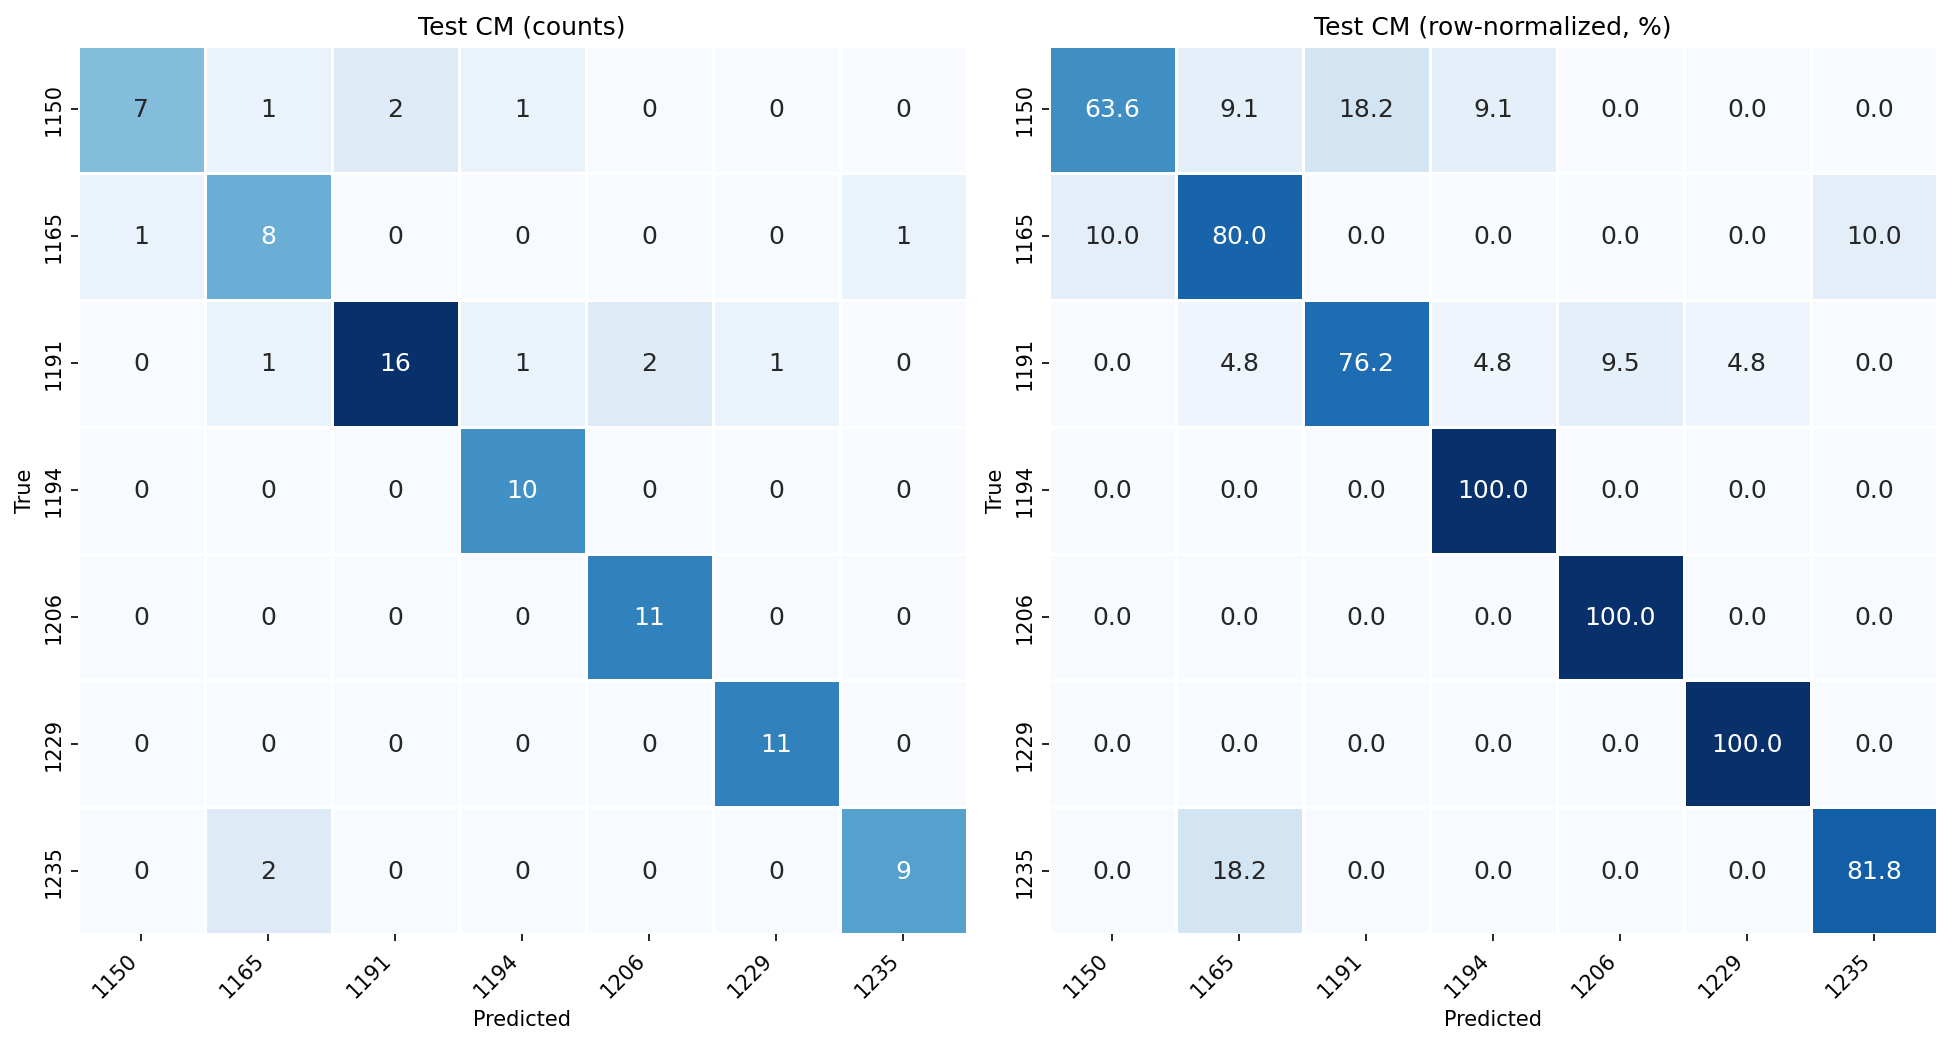

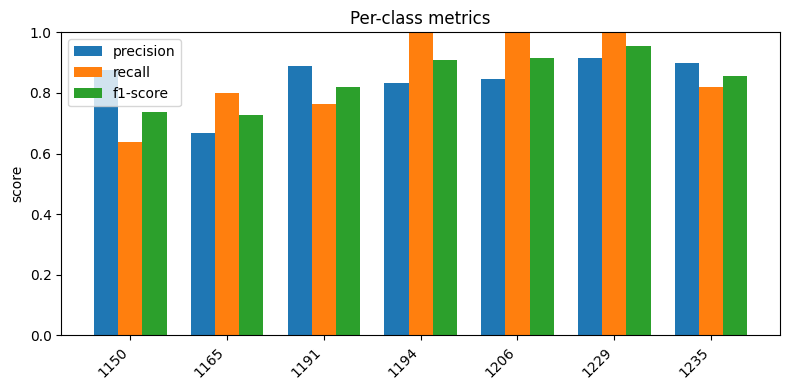

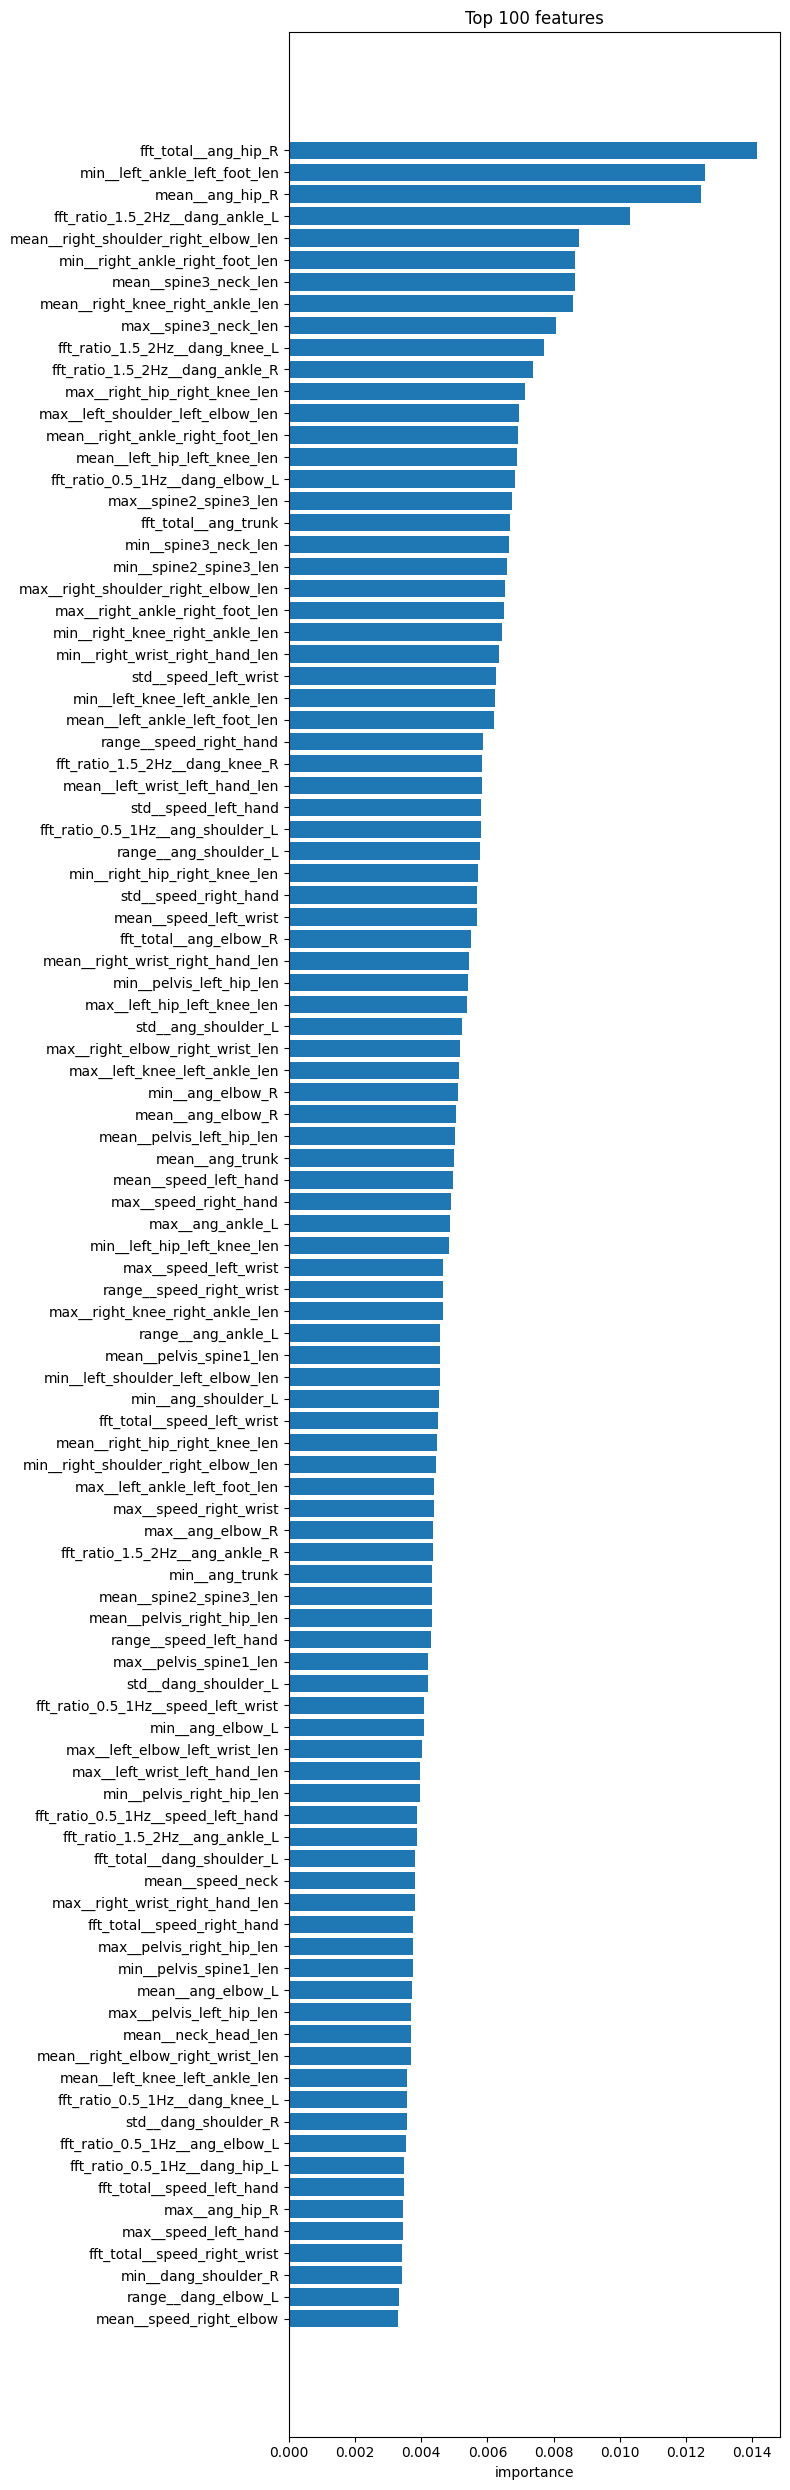

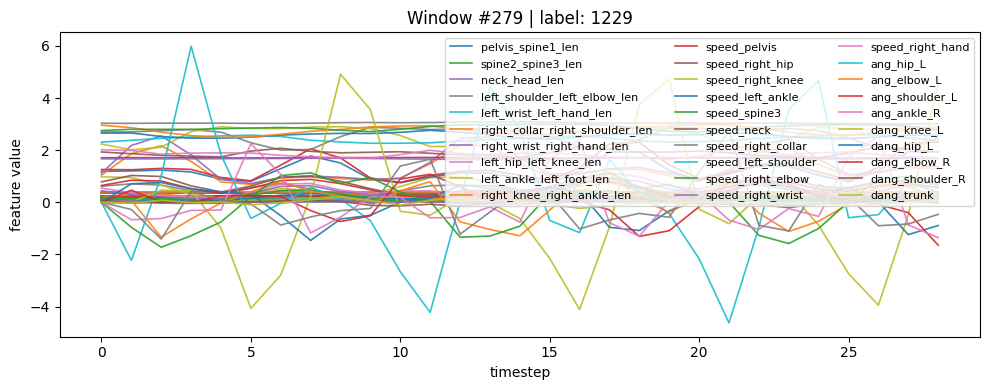

In [15]:
# === Plotting usage (fixed: consistent label types) ===
import numpy as np
import os
import seaborn as sns

y_test_pred_lbl = le.inverse_transform(y_test_pred)

labels_sorted = sorted(le.classes_, key=str)

# 1) Confusion matrices (both y_true and y_pred are strings)
plot_confusion_matrices(y_test, y_test_pred_lbl, savepath="figs/cm_test.png", title_prefix="Test CM")

# 2) Per-class precision/recall/F1 bars
plot_per_class_report(y_test, y_test_pred_lbl, labels=labels_sorted)

# 4) Feature importances 
feature_names = stats_col+fft_names  # <-- matches X_train_f columns 1:1
plot_feature_importances(best_rf, feature_names, top_n=100)

# Random window plots per-timestep features (so use per-frame names, not stats names)
plot_random_window(X_train, y_train, feature_names=feat_cols)



Test accuracy: 0.8588235294117647
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        11
           1       0.67      0.60      0.63        10
           2       0.89      0.81      0.85        21
           3       0.91      1.00      0.95        10
           4       0.85      1.00      0.92        11
           5       0.85      1.00      0.92        11
           6       0.90      0.82      0.86        11

    accuracy                           0.86        85
   macro avg       0.85      0.86      0.85        85
weighted avg       0.86      0.86      0.86        85

Saved confusion matrices to figs/cm_test_fixedrf.png


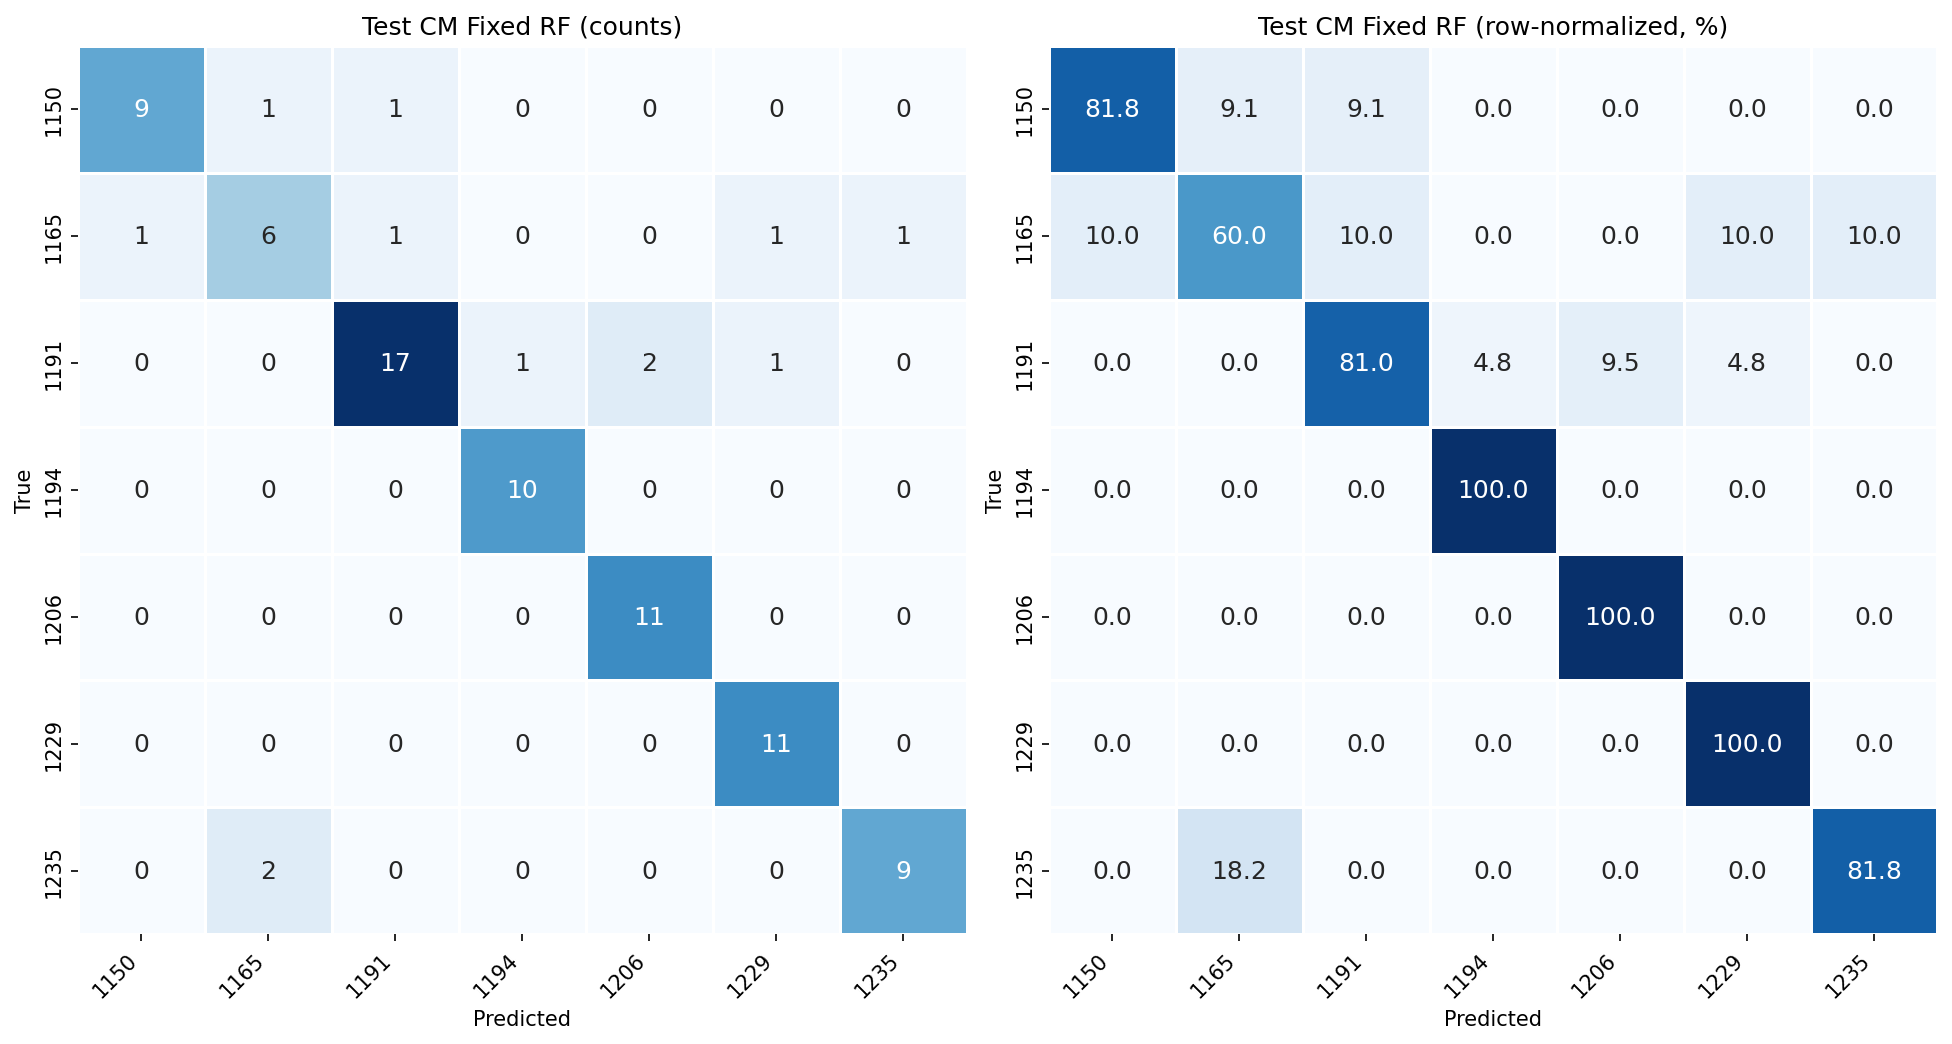

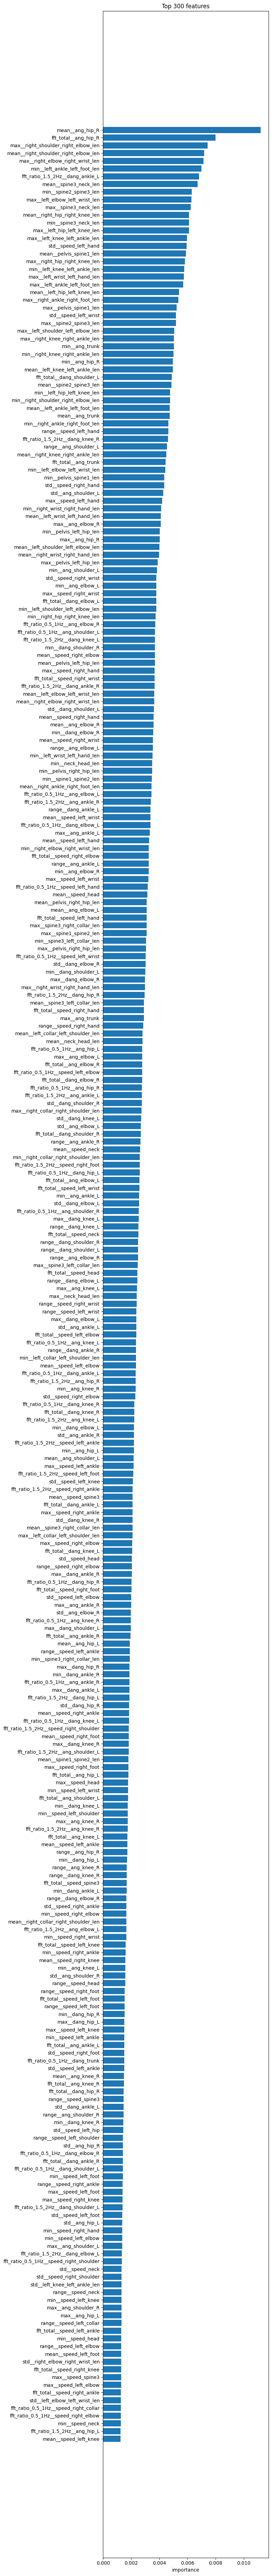

In [16]:

rf = BalancedRandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    n_estimators=400,
    max_depth=10,
    max_features='log2',
    min_samples_split=2,
    min_samples_leaf=1,
)
rf.fit(X_train_f, y_train_enc)
y_test_pred = rf.predict(X_test_f)
print("Test accuracy:", accuracy_score(y_test_enc, y_test_pred))
print(classification_report(y_test_enc, y_test_pred, zero_division=0))
y_test_pred_lbl = le.inverse_transform(y_test_pred)
plot_confusion_matrices(y_test, y_test_pred_lbl, savepath="figs/cm_test_fixedrf.png", title_prefix="Test CM Fixed RF")
import numpy as np
import pandas as pd
plot_feature_importances(rf, feature_names, top_n=300)

